# Drought Impacts on Illinois Groundwater

## Overview

This notebook picks up where `intro_base_model.ipynb` left off. We **modify** the IISG base
groundwater model to simulate a drought scenario and analyze its effects on regional water levels.

A drought is represented as a sustained **reduction in recharge** — the process by which
precipitation and surface water replenish the aquifer. When recharge drops, the aquifer is no
longer being refilled at its usual rate, and water levels (heads) gradually decline. This notebook
lets you explore *how much* and *where* those declines occur across the model domain.

### What you will learn
1. How to **copy** an existing MODFLOW 6 simulation to a new workspace
2. How to convert a **steady-state** model to a **transient** (time-varying) simulation
3. How to add **storage** parameters (specific storage and specific yield)
4. How to update **recharge** to represent drought conditions
5. How to run the modified simulation and **post-process** results
6. How to explore results using **static maps**, **hydrographs**, and an **interactive dashboard**

### Drought Scenario Definition
- **Recharge reduction**: 50% of normal (base model) recharge — representing a prolonged dry period
- **Duration**: one year (365.25 days) as a single stress period
- **Initial conditions**: steady-state heads from the base model

### Workshop Context

This is one of three scenario notebooks that build on `intro_base_model.ipynb`:

| Notebook | Scenario |
|---|---|
| `new_demands.ipynb` | New large-scale pumping demand |
| **-- `drought_impacts.ipynb`** | **Reduced recharge representing a drought (this notebook) --** |
| `gw_age.ipynb` | Groundwater age and transport modeling |

Each scenario uses the same base model but explores a different type of stress on the aquifer system.

> **Note — Educational Use Only.** The base model is built from real-world geology and
> hydrodynamic data for Chicago's South Suburbs, but simplifying assumptions have been made
> to reduce its size and runtime. Results should **not** be used for planning or decision-making;
> they are intended for exploration and education.

## Imports

The same core libraries used in `intro_base_model.ipynb` are needed here, plus a few additions
for working with tabular and geospatial data.

We also import three items from `helper_functions.py` — a module written specifically for this
notebook that lives in the same `python_notebooks/` directory:

| Helper | Purpose |
|---|---|
| `extract_transient_data` | Reads head arrays from MODFLOW output and computes drawdown across all time steps |
| `build_static_features` | Converts model grid features (wells, streams, boundaries) into GeoJSON for map display |
| `DroughtDashboard` | An interactive widget-based dashboard combining an ipyleaflet map and a matplotlib hydrograph |

You can call `help(DroughtDashboard)` (or `help(extract_transient_data)`, `help(build_static_features)`)
directly in a cell to read the full documentation for any of these helpers.

In [1]:
# Standard Library Imports
from pathlib import Path

# Scientific Stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Domain-Specific Packages (Flopy)
import flopy

## More advanced ##

# GIS "aids"
import geopandas as gpd

# Custom functions and an interactive dashboard "Class"
# See helper_functions.py file in the python_notebooks directory if 
# you want to see the code.
from helper_functions import extract_transient_data, build_static_features, DroughtDashboard

# Or call
help(DroughtDashboard) # or help(extract_transient_data), help(build_static_features)
# To display documentation for the custom features

Help on class DroughtDashboard in module helper_functions:

class DroughtDashboard(builtins.object)
 |  DroughtDashboard(gwf, data, static_features, layer=8)
 |
 |  Interactive dashboard with globally anchored limits and map hovering.
 |
 |  This class provides a user interface combining an ipyleaflet map and a
 |  matplotlib plot to explore transient groundwater model results (heads
 |  and drawdown) across multiple time steps.
 |
 |  Parameters
 |  ----------
 |  gwf : flopy.mf6.ModflowGwf
 |      The active MODFLOW 6 groundwater flow model object.
 |  data : dict
 |      A dictionary containing extracted transient data including times,
 |      4D head arrays, 4D drawdown arrays, and hydrograph DataFrames.
 |  static_features : dict
 |      A dictionary of GeoJSON objects and GeoDataFrames representing
 |      static model features (e.g., bounding box, counties, streams, wells, ghb).
 |  layer : int, optional
 |      The zero-indexed model layer to visualize on the map. Default is 8.

## Housekeeping

We define the same directory structure and path constants as in `intro_base_model.ipynb`.
The key addition here is the `updated_model_workspace` path — this is the directory where
all input and output files for the drought simulation will be written.

Using `pathlib.Path` objects (rather than plain strings) ensures that file paths work
correctly on Windows, macOS, and Linux without any manual adjustments.

In [2]:
# Use pathlib to get this notebook's location
notebook_dir = Path.cwd()
# home_dir = notebook_dir.parents[2]
home_dir = notebook_dir.parent

sim_name = "mfsim"

base_model_workspace    = home_dir / "modflow_models" / "iisg_local_model"
updated_model_workspace = home_dir / "modflow_models" / "drought_impact_model"

exe_name = home_dir / "bin" / "mf6.exe"
# shp_path = home_dir / "data" / "background_shapefiles" / "counties_5070.shp"
shp_path = home_dir / "shapefiles" / "counties_5070.shp"

print("Base model workspace :", base_model_workspace)
print("Drought model workspace:", updated_model_workspace)

Base model workspace : C:\Users\dbabrams\Documents\GitHub\ISWS-Chi-Water-Week_2026\modflow_models\iisg_local_model
Drought model workspace: C:\Users\dbabrams\Documents\GitHub\ISWS-Chi-Water-Week_2026\modflow_models\drought_impact_model


## Load the Base Model and Heads

Before we can create the drought scenario, we need the **base model** and its **steady-state heads**.
The base heads serve two critical roles:

1. **Initial conditions** for the transient drought simulation — the aquifer starts at steady-state
   before drought begins.
2. **Baseline** for calculating drawdown: `drawdown = drought_heads − base_heads`.

In [3]:
# Load the base simulation
base_sim = flopy.mf6.MFSimulation.load(
    sim_name=sim_name,
    sim_ws=base_model_workspace,
    write_headers=False,
    exe_name=exe_name
)

# Extract the groundwater flow model
base_model_name = list(base_sim.model_names)[0]
base_gwf = base_sim.get_model(base_model_name)

# Retrieve the model grid dimensions for later use
nrow = base_gwf.modelgrid.nrow
ncol = base_gwf.modelgrid.ncol
nlay = base_gwf.modelgrid.nlay

# Read the layer bottom elevations (needed for dry-cell handling)
layer_botm_elevations = base_gwf.modelgrid.botm

print(f"Base model loaded: {base_model_name}")
print(f"Grid: {nlay} layers x {nrow} rows x {ncol} cols")

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package rch...
    loading package oc...
    loading package ghb...
    loading package sfr...
    loading package wel...
    loading package obs...
    loading package drn...
  loading solution package gwf-iisg...
Base model loaded: gwf-iisg
Grid: 10 layers x 847 rows x 569 cols


In [4]:
# Read steady-state heads from the base model output
base_head_file = base_gwf.output.head()
base_times     = base_head_file.get_times()
base_heads     = base_head_file.get_data(totim=base_times[-1])

# Replace MODFLOW's dry/inactive sentinel value (>1e20) with the layer bottom elevation.
# This prevents arithmetic errors in later calculations.
base_heads = np.where(base_heads > 1e20, layer_botm_elevations, base_heads)

print(f"Base heads loaded for time: {base_times[-1]}")
print(f"Head array shape: {base_heads.shape}")

Base heads loaded for time: 1.0
Head array shape: (10, 847, 569)


## Copying the Base Model to a New Workspace

To avoid modifying the original base model files, we create a copy of the simulation
in a new directory (`drought_impact_model/`). We use a two-step trick:

1. **Temporarily** redirect the simulation's internal path to the new workspace.
2. Call `write_simulation()` — FloPy writes all input files to the new location.
3. **Restore** the original path so the `base_sim` object still points to the base model.


In [5]:
# "Copy" the base model to the new model workspace by temporarily updating the path
# and calling the write_simulation method.
# There are more elegant (and perhaps more correct) ways to accomplish, but this method only
# requires 2 lines of code :)
base_sim.set_sim_path(updated_model_workspace)
base_sim.write_simulation()

# Undo the horrible thing that was done
base_sim.set_sim_path(base_model_workspace)

print("\n-- Success! Base model copied to new workspace --\n")

# Load the newly created drought simulation
drought_sim = flopy.mf6.MFSimulation.load(
    sim_name=sim_name,
    sim_ws=updated_model_workspace,
    write_headers=False,
    exe_name=exe_name
)

print("\n-- Success! Drought simulation loaded --\n")

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package gwf-iisg...
  writing model gwf-iisg...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package oc...
    writing package ghb_0...
    writing package sfr_obs...
    writing package sfr_0...
    writing package wel_obs...
    writing package wel_0...
    writing package obs_1...
    writing package drn_0...

-- Success! Base model copied to new workspace --

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package rch...
    loading package oc...
    loading package ghb...
    loading package sfr...
    loading package wel...
    loading package obs...
    loading package drn...
  loading solution package gwf-iisg...



### Extract the Drought Groundwater Flow Model

Just as with the base model, we extract the `gwf` model object from the newly loaded simulation.
All subsequent modifications will be applied to `drought_gwf`.

In [6]:
# Just like with the base model let's extract the groundwater flow model

drought_model_name = list(drought_sim.model_names)[0]

print(drought_model_name)

drought_gwf = drought_sim.get_model(drought_model_name)

# Surprise, surprise it's the same model name as our base model
# We could rename our model via:
# drought_gwf.rename_all_packages("gwf-iisg-drought")
# But we won't :)

print(Path(drought_gwf.model_ws) == updated_model_workspace)

gwf-iisg
True


## Configuring the Drought Scenario: Modifying Recharge (RCH)

In the base model, our aquifer receives a steady rate of replenishment from precipitation, represented by the Recharge (RCH) package. To simulate a drought, we must significantly reduce this incoming water.

---

### 🌌 A Water Modeling Parable: Altering the Deal

>  In Cloud City, Lando Calrissian thinks he has a stable, manageable arrangement to protect his colony. But **Darth Vader**, representing an overwhelming, uncontrollable external force, arbitrarily changes the boundary conditions of their agreement. Lando realizes he has absolutely no control over the situation: *"I am altering the deal. Pray I don't alter it any further."*

>  In water supply planning, climate and weather are Darth Vader. We build our infrastructure and communities based on historical "deals" (average annual rainfall). A severe drought alters that deal, changing the fundamental boundary conditions of our aquifer. We cannot negotiate with a drought or engineer our way out of it by simply drilling more wells; we must use our models to anticipate the new terms and adapt our society to survive them.

---

In the cell below, we define two parameters to represent this harsh new reality:

| Parameter | Value | Meaning |
|---|---|---|
| `drought_factor` | 0.5 | Recharge is 50% of baseline — a severe drought |
| `drought_length` | 365.25 days | One full year of drought conditions |

These are intentionally kept as simple, adjustable constants so that sensitivity analysis
is straightforward — just change the values and re-run the notebook.

In [7]:
drought_factor = 0.5   # Reduce model recharge by drought_factor * base_model recharge
drought_length = 365.25 # Days

## Converting from Steady-State to Transient

The base model is a **steady-state** simulation — it has no time dimension.
To simulate drought impacts over time, we must convert it to a **transient** simulation
with one or more stress periods.

### MODFLOW Time Discretization (TDIS) Package
The TDIS package controls:
- The number of **stress periods** (distinct blocks of time with constant boundary conditions)
- The **length** of each stress period (days)
- The number of **time steps** within each stress period
- The **time-step multiplier** (allows non-uniform time steps within a period)

For our scenario, we use a single one-year stress period with a time-step multiplier of 1.5
(geometric time stepping). We first inspect the existing TDIS data before modifying it.

In [8]:
drought_time_dis = drought_sim.get_package("tdis")

print(drought_time_dis.perioddata.get_data())

[(1., 1, 1.)]


In [9]:
num_periods = 1
time_steps = 20
period_length = [drought_length] * num_periods
num_steps = [time_steps] * num_periods
timestep_mult = [1.5] * num_periods
drought_time_dis.perioddata = list(zip(period_length, num_steps, timestep_mult))

print(drought_time_dis.perioddata.get_data())

[(365.25, 20, 1.5)]


In [10]:
def calculate_timesteps(perlen, nstp, tsmult):
    r"""
    Calculate time step lengths for a stress period using a geometric progression.

    Parameters
    ----------
    perlen : float
        Total length of the stress period.
    nstp : int
        Number of time steps in the stress period.
    tsmult : float
        Multiplier for the length of successive time steps. If 1.0, 
        time steps are of equal length.

    Returns
    -------
    steps : ndarray
        1D array of floats containing the length of each time step.

    Notes
    -----
    The length of the first time step (dt1) is calculated as:
    dt1 = perlen * (1 - tsmult) / (1 - tsmult^nstp)

    The rest of the timesteps are calculated as:
    dt1 * (tsmult ^ [0,1,2, ..., nstp]) -> 
                                        [dt1, dt1*tsmult, dt1*tsmult^2, ..., dt1*tsmult^nstp]
    """
    
    if tsmult == 1.0:
        return np.full(nstp, perlen / nstp)
    # "Vectorized" geometric progression
    dt1 = perlen * (1 - tsmult) / (1 - tsmult**nstp)
    return dt1 * (tsmult ** np.arange(nstp))

In [11]:
for p in range(num_periods):
    steps = calculate_timesteps(period_length[p], num_steps[p], timestep_mult[p])
    
    # Format all steps into a single string block
    steps_output = "\n".join([f"Timestep {i+1:2}: {val:.6f} days" for i, val in enumerate(steps)])
    
    print(f"--- Period {p+1} ---\n{steps_output}")
    print(f"Total Period Length: {sum(steps):.2f} days\n")

--- Period 1 ---
Timestep  1: 0.054937 days
Timestep  2: 0.082406 days
Timestep  3: 0.123608 days
Timestep  4: 0.185413 days
Timestep  5: 0.278119 days
Timestep  6: 0.417179 days
Timestep  7: 0.625768 days
Timestep  8: 0.938652 days
Timestep  9: 1.407978 days
Timestep 10: 2.111966 days
Timestep 11: 3.167950 days
Timestep 12: 4.751924 days
Timestep 13: 7.127887 days
Timestep 14: 10.691830 days
Timestep 15: 16.037745 days
Timestep 16: 24.056617 days
Timestep 17: 36.084926 days
Timestep 18: 54.127389 days
Timestep 19: 81.191083 days
Timestep 20: 121.786625 days
Total Period Length: 365.25 days



## Adding the Storage (STO) Package

Transient simulations require a **Storage (STO) package** that tells MODFLOW how much water
can be released from storage as heads decline. The two key parameters are:





We first check if a STO package already exists (it would if the base model were already transient),
and only add one if it is missing.

## Adding the Storage Package (STO)

Because we are running a transient simulation where our primary input of water (recharge) has been severely reduced, we must add a **Storage (STO) package**. This package tells MODFLOW how much water the aquifer can yield from its own physical matrix as water levels decline.

| Parameter | Symbol | Typical Range | Description |
|---|---|---|---|
| Specific Storage | Ss | 10⁻⁶ – 10⁻⁴ m⁻¹ | Volume of water released per unit volume of aquifer per unit head decline (confined) |
| Specific Yield | Sy | 0.05 – 0.35 | Volume of water released per unit area per unit head decline (unconfined) |

- `iconvert = 1` tells MODFLOW to automatically switch between confined and unconfined storage
  formulations based on the simulated head in each cell.
- `steady_state = False` and `transient = True` override the inherited steady-state flag
  so MODFLOW knows to use the storage terms.

---

### 🌌 A Water Modeling Parable: The Shield Generator on Hoth

>  The Rebel base on the ice planet Hoth survives the initial Imperial bombardment solely because of their DSS-02 shield generator. Once the shield is taken down, the base is immediately vulnerable to the walkers, forcing a desperate evacuation.

>  Normal annual precipitation (recharge) is our shield generator. It actively deflects and offsets the stress of daily human pumping. During a severe drought, that shield is turned off. At that point, the system relies entirely on the finite volume of water physically stored in the geologic matrix—our Specific Yield and Specific Storage. Modeling a drought teaches us exactly how long our "Echo Base" can hold out against the continuous bombardment of pumping before our storage is depleted and the wells run dry.

---

In the code below, we configure the STO package to allow the model to draw from this finite structural storage.

We first check if a STO package already exists (it would if the base model were already transient), and only add one if it is missing.

In [12]:
if drought_gwf.get_package("sto") is None:
    sto = flopy.mf6.ModflowGwfsto(
        drought_gwf,
        save_flows=True,
        iconvert=1,
        ss=1e-5,
        sy=0.15,
        steady_state=False,
        transient=True
    )

print(f"Specific Storage (Ss): {drought_gwf.sto.ss.array}")
print(f"Specific Yield (Sy): {drought_gwf.sto.sy.array}")

Specific Storage (Ss): [[[1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  ...
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]]

 [[1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  ...
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]]

 [[1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  ...
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]
  [1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-05]]

 ...

 [[1.e-05 1.e-05 1.e-05 ... 1.e-05 1.e-05 1.e-0

## Updating Initial Conditions

For a transient simulation, MODFLOW requires **initial head values** that represent conditions
at the start of the simulation (time = 0).

We use the **steady-state heads from the base model** as our starting point.
This is physically meaningful: the aquifer is assumed to be at its long-term equilibrium
before the drought begins.

The Initial Conditions (IC) package stores these starting heads as a 3D array.

In [13]:
# Replace the initial conditions with the base model steady-state heads
ic = flopy.mf6.ModflowGwfic(drought_gwf, strt=base_heads)

print("Initial Conditions updated")

Initial Conditions updated


## Updating Stress Period Data

In a transient simulation, stress packages (like wells and recharge) must provide data
for **each stress period**. The base model is steady-state and only has one period's worth of data.
We need to:

1. **Wells (WEL package)**: Copy the base pumping rates to all transient stress periods.
   We assume pumping continues unchanged during the drought.
2. **Recharge (RCHA package)**: Copy the base recharge and multiply by `drought_factor` (0.5)
   to represent reduced infiltration during the drought period.

The code checks whether each package exists before modifying it, making it robust
to models that may not have all these packages.

In [14]:
# Check for a WEL package, if it exists expand its data to all periods
if drought_gwf.get_package("wel"):
    wel = drought_gwf.get_package("wel")
    base_data = wel.stress_period_data.get_data(0)  # from steady-state
    wel_data = {per: base_data for per in range(num_periods)}
    wel.stress_period_data.set_data(wel_data)
    print("WELl package updated successfully.")
else: print("No WELl package found.")

WELl package updated successfully.


In [15]:
# Check for a RCH package, expand its data to all periods and modify for drought
if drought_gwf.get_package("rcha_0"):
    base_rch_data = base_gwf.get_package("rcha_0").recharge.array[0]  # from steady-state
    drought_rch = drought_gwf.get_package("rcha_0")
    drought_rch_data = {per: drought_factor*base_rch_data for per in range(num_periods)}
    drought_rch.recharge.set_data(drought_rch_data)
    print(drought_rch.recharge.array[0] / base_rch_data)
    print("ReCHArge package updated successfully.")
else: print("No ReCHArge package found.")

[[[0.5 0.5 0.5 ... nan nan nan]
  [0.5 0.5 0.5 ... nan nan nan]
  [0.5 0.5 0.5 ... nan nan nan]
  ...
  [0.5 0.5 0.5 ... 0.5 0.5 0.5]
  [0.5 0.5 0.5 ... 0.5 0.5 0.5]
  [0.5 0.5 0.5 ... 0.5 0.5 0.5]]]
ReCHArge package updated successfully.


## Configuring Model Observations

MODFLOW's **OBS utility** package lets us record simulated heads at specific cell locations
throughout the transient run. These time-series records are written to CSV files after the
simulation and are the raw data that power the hydrograph plots and interactive dashboard
later in this notebook.

Here we replace any observation packages carried over from the base model with a fresh,
**uniform grid** of observation points spread across the model domain. Each observation point:

- Is placed in **Layer 9** (index 8), the primary aquifer layer of interest
- Is spaced **every 50 cells** in both row and column directions
- Is only added if the cell is **active** (idomain = 1) — inactive or dry cells are skipped
- Is given a machine-readable name like `gh_l9_r51_c101` (layer, row, column in 1-based indices)

This grid-based approach gives a spatial snapshot of drought drawdown across the entire aquifer,
rather than limiting observations to a handful of predetermined monitoring locations.

We also recreate the **Output Control (OC)** package so that head and budget data are saved
for *every* time step — not just the final one. This is required for animating the dashboard.

In [16]:
# Replace existing OBS package with uniform grid head observations

# Define observation grid parameters
obs_spacing = 50
obs_layer = 8  # zero-based; 0 = model layer 1
edge_buffer = 5

idomain = drought_gwf.dis.idomain.array[obs_layer]
nrow, ncol = idomain.shape

grid_head_obs = []

# Iterate through the grid, starting after the buffer and stopping before the far edge
for row in range(edge_buffer, nrow - edge_buffer, obs_spacing):
    for col in range(edge_buffer, ncol - edge_buffer, obs_spacing):
        # Only place observation points in active model cells
        if idomain[row, col] == 1:
            obsname = f"gh_l{obs_layer + 1}_r{row + 1}_c{col + 1}"
            grid_head_obs.append((obsname, "HEAD", (obs_layer, row, col)))

# Remove old observation packages to prevent conflicts and ensure
# we are only tracking the data relevant to the current scenario
for obs_pname in ["obs_0", "obs_1", "grid_head_obs"]:
    if drought_gwf.get_package(obs_pname):
        drought_gwf.remove_package(obs_pname)

# Initialize the new custom observation package
flopy.mf6.ModflowUtlobs(
    drought_gwf,
    pname="obs_0",
    filename=f"{drought_gwf.name}.obs",
    digits=10,
    print_input=True,
    continuous={
        "grid_head_obs.csv": grid_head_obs
    },
)

print(f"Replaced OBS package with {len(grid_head_obs)} buffered grid head observations.")

Replaced OBS package with 141 buffered grid head observations.


In [17]:
# --- Update Output Control (OC) ---

# 1. Remove the old Output Control package completely to clear out old data structures
if drought_gwf.get_package('oc'):
    drought_gwf.remove_package('oc')

# 2. Create a fresh Output Control package, explicitly defining the output files!
oc = flopy.mf6.ModflowGwfoc(
    drought_gwf,
    pname='oc',
    head_filerecord=f"{drought_gwf.name}.hds",
    budget_filerecord=f"{drought_gwf.name}.cbc",
    saverecord=[('HEAD', 'ALL'), ('BUDGET', 'ALL')]
)

print("Old OC package removed. Fresh OC package added with file records to save all timesteps.")

Old OC package removed. Fresh OC package added with file records to save all timesteps.


## Running the Drought Simulation

`write_simulation()` writes all updated package files to the `drought_impact_model/` directory,
then `run_simulation()` launches the MODFLOW 6 executable.

MODFLOW will print a run log to the console. Look for **"Normal termination"** at the end,
which confirms the simulation converged successfully.

## Writing and Running the Drought Simulation

`write_simulation()` writes all updated package files to the `drought_model/` directory, then `run_simulation()` launches the MODFLOW 6 executable.

---

### 🌌 A Water Modeling Parable: The Cave on Dagobah
>  When Luke enters the dark side cave on Dagobah, he asks Yoda what is in there. Yoda replies, *"Only what you take with you."* Luke takes his weapons and his fear, and consequently fights an illusion of Darth Vader, which is revealed to have his own face.

>  A groundwater model running a severe drought scenario is exactly like that cave. The model does not inherently know what a "drought" is; it only knows the geological parameters, grid discretization, and boundary conditions we coded into it. If our model predicts catastrophic failure or dry cells during a drought, it is reflecting our own assumptions back at us. A stress test reveals the flaws, uncertainties, and blind spots in our own understanding of the subsurface.

---

Because we are drastically reducing recharge, you may see **convergence warnings** in the console output below. This happens when the model struggles to balance the water budget under extreme stress, and cells begin to go dry. When you see those warnings, remember the cave: the model is simply showing you the limits of the conceptual system you took in with you.

>If you see convergence warnings or errors consider:
>  - Reducing the time-step length (increase `num_steps`)
>  - Checking that storage parameters are physically reasonable

In [18]:
drought_sim.write_simulation()
print("\n-- Success! Drought simulation written. --\n")
drought_sim.run_simulation()
print("\n-- Success! Drought simulation run. --\n")

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package gwf-iisg...
  writing model gwf-iisg...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package rcha_0...
    writing package ghb_0...
    writing package sfr_obs...
    writing package sfr_0...
    writing package wel_obs...
    writing package wel_0...
    writing package drn_0...
    writing package sto...
    writing package ic...
    writing package obs_0...
    writing package oc...

-- Success! Drought simulation written. --

FloPy is using the following executable to run the model: ..\..\bin\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.5.0 05/23/2024

   MODFLOW 6 compiled May 23 2024 18:06:57 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0


## Post-Processing and Visualizing Results

Now that the drought simulation has run, we work through three layers of analysis:

1. **Static contour maps** — one map per model layer showing the spatial pattern of drawdown
   at the end of the drought period
2. **Anomaly detection** — identifying cells where heads *rose* during the drought (physically
   unexpected) and exporting them for further investigation
3. **Hydrographs and the interactive dashboard** — time-series head plots and a live
   ipyleaflet map that lets you step through time steps and click on observation wells

### Drawdown Sign Convention

$$\text{drawdown} = \text{drought heads} - \text{base heads}$$

Because drought reduces heads, drawdown values will be **negative** in affected areas.
Unexpectedly **positive** values indicate areas where boundary conditions (e.g., Lake Michigan
or streamflow) are supplying enough water to partially offset the recharge reduction.

In [19]:
# Read drought heads from the simulation output
drought_head_file = drought_gwf.output.head()

drought_times     = drought_head_file.get_times()
drought_heads     = drought_head_file.get_data(totim=drought_times[-1])


# Replace dry/inactive sentinel values
drought_heads     = np.where(drought_heads > 1e20, layer_botm_elevations, drought_heads)

print(f"Drought heads loaded for time: {drought_head_file.get_times()[-1]}")

Drought heads loaded for time: 365.25


### Computing Drawdown

Drawdown is the change in groundwater head between the pre-drought (base) and
post-drought (drought) conditions. A negative value indicates the water table fell;
a positive value is anomalous and warrants further investigation.

In [20]:
drawdown = drought_heads - base_heads  # positive = head rose; negative = head fell

# Alternatively
drawdown_alt = drought_heads - drought_gwf.ic.strt.array

assert np.array_equal(drawdown, drawdown_alt), "Uh-oh!"

print("tomato, tomato.\n")

print(drawdown[8])

tomato, tomato.

[[-0.95754226 -0.95511006 -0.95029593 ...  0.          0.
   0.        ]
 [-0.9590075  -0.95660553 -0.95187552 ...  0.          0.
   0.        ]
 [-0.96192148 -0.95958983 -0.95499131 ...  0.          0.
   0.        ]
 ...
 [-0.04961182 -0.04986094 -0.050394   ... -8.08004861 -8.08893702
  -8.09541133]
 [-0.04972073 -0.04992214 -0.05030464 ... -8.13047477 -8.13749534
  -8.14528297]
 [-0.04975733 -0.04992295 -0.05022126 ... -8.15349355 -8.16157917
  -8.17112501]]


### Drawdown Contour Maps by Layer

The loop below creates a **contour map** of drawdown for every model layer.

Key elements:
- **Contour lines**: 10 evenly spaced intervals from the minimum drawdown to zero
- **Red contours** (using the `Reds_r` colormap): darker colors = larger (more negative) drawdown
- **Green squares**: pumping well locations (Layer 9 only)
- **Blue squares**: stream reaches (SFR package, Layer 1)

Comparing the drawdown pattern with well and stream locations can reveal how
combined stresses interact during drought.

Layer 1 Drawdown Statistics ->
  Min: -35.97
  Max: 0.00
  Median: -0.18
  Mean: -1.86
  Histogram: (array([   534,   1845,   8037,   5572,   4628,   5004,   5123,   5964,
        11756, 433480]), array([-35.96831641, -32.37148477, -28.77465313, -25.17782149,
       -21.58098985, -17.9841582 , -14.38732656, -10.79049492,
        -7.19366328,  -3.59683164,   0.        ]))

------------------------------------------------------------


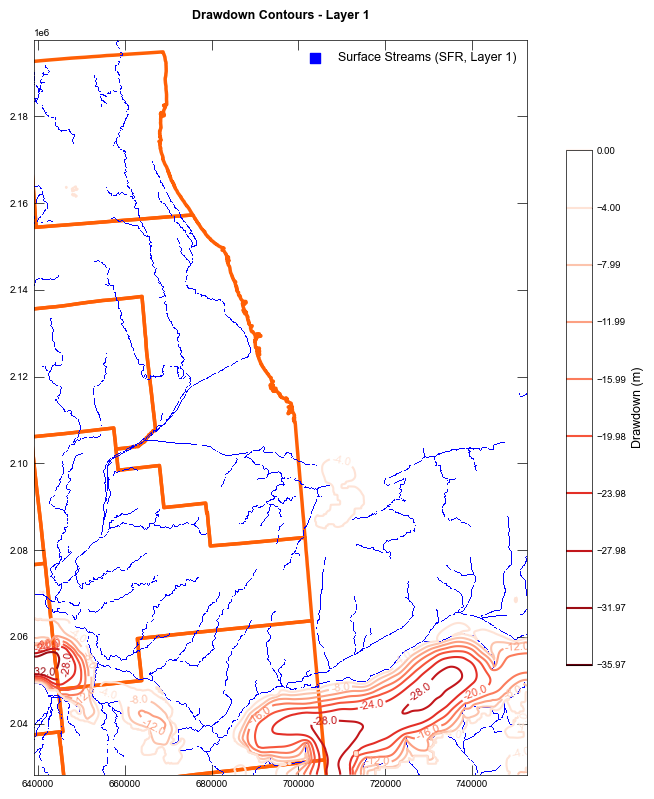

Layer 2 Drawdown Statistics ->
  Min: -35.97
  Max: 0.00
  Median: -0.17
  Mean: -1.85
  Histogram: (array([   534,   1845,   8036,   5571,   4627,   5007,   5123,   5968,
        11716, 433516]), array([-35.96828572, -32.37145715, -28.77462858, -25.1778    ,
       -21.58097143, -17.98414286, -14.38731429, -10.79048572,
        -7.19365714,  -3.59682857,   0.        ]))

------------------------------------------------------------


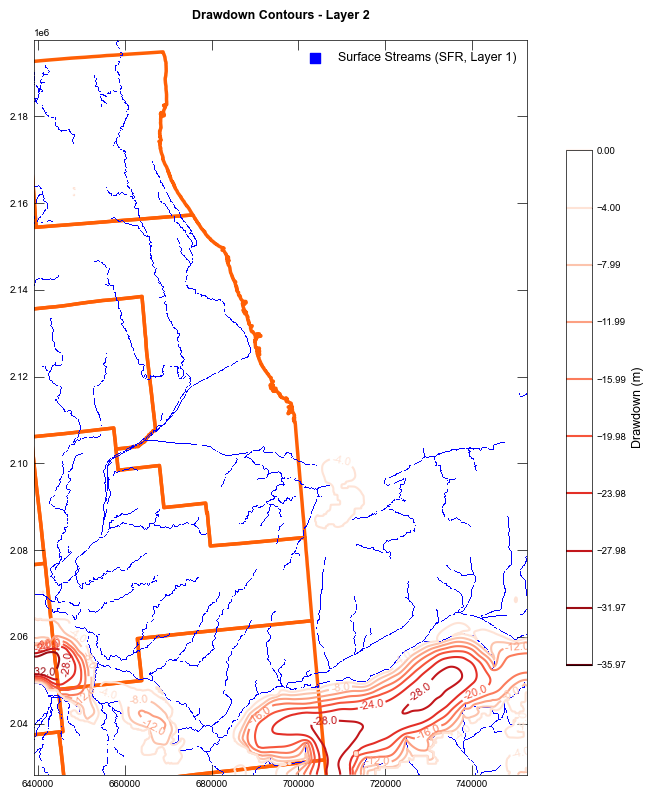

Layer 3 Drawdown Statistics ->
  Min: -35.97
  Max: 0.00
  Median: -0.17
  Mean: -1.84
  Histogram: (array([   534,   1839,   8042,   5569,   4629,   5010,   5119,   5974,
        11703, 433524]), array([-35.96823846, -32.37141462, -28.77459077, -25.17776692,
       -21.58094308, -17.98411923, -14.38729539, -10.79047154,
        -7.19364769,  -3.59682385,   0.        ]))

------------------------------------------------------------


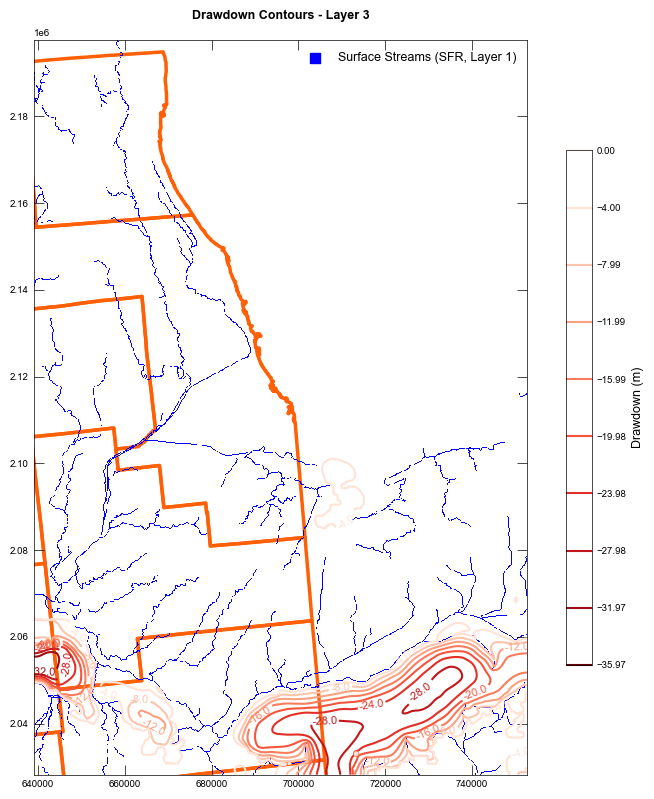

Layer 4 Drawdown Statistics ->
  Min: -35.97
  Max: 0.00
  Median: -0.16
  Mean: -1.84
  Histogram: (array([   533,   1839,   8042,   5570,   4629,   5009,   5116,   5978,
        11695, 433532]), array([-35.96643687, -32.36979318, -28.77314949, -25.17650581,
       -21.57986212, -17.98321843, -14.38657475, -10.78993106,
        -7.19328737,  -3.59664369,   0.        ]))

------------------------------------------------------------


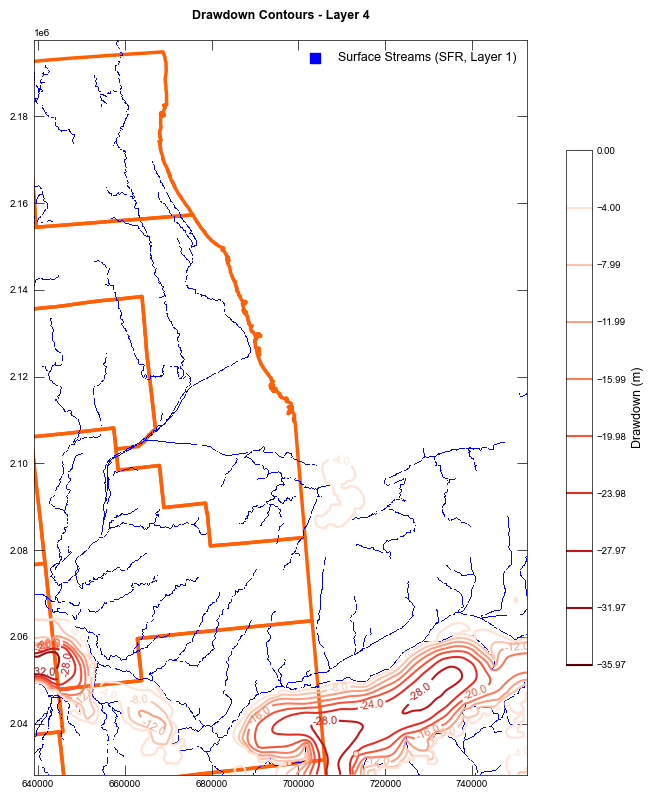

Layer 5 Drawdown Statistics ->
  Min: -35.96
  Max: 0.00
  Median: -0.16
  Mean: -1.84
  Histogram: (array([   532,   1840,   8041,   5570,   4628,   5010,   5114,   5965,
        11728, 433515]), array([-35.96469236, -32.36822312, -28.77175389, -25.17528465,
       -21.57881541, -17.98234618, -14.38587694, -10.78940771,
        -7.19293847,  -3.59646924,   0.        ]))

------------------------------------------------------------


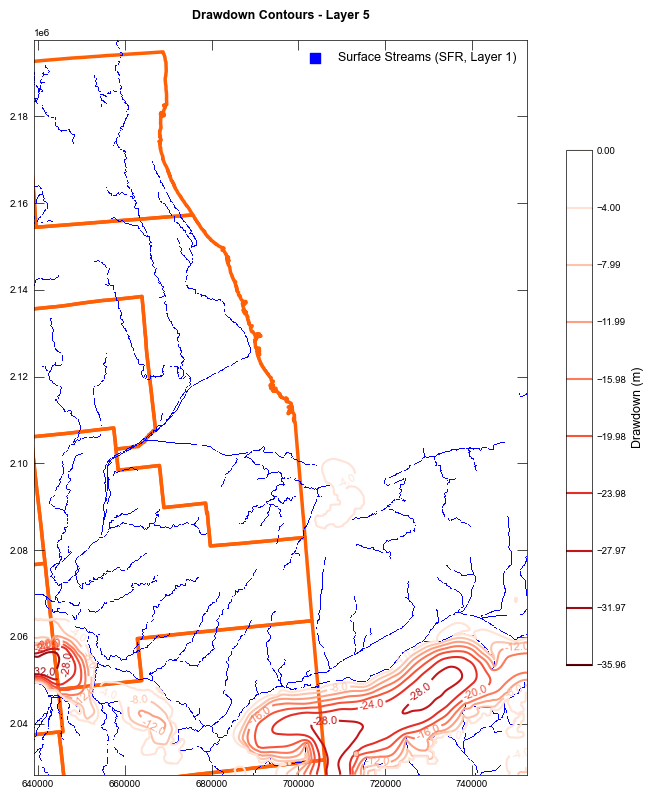

Layer 6 Drawdown Statistics ->
  Min: -35.96
  Max: 0.00
  Median: -0.16
  Mean: -1.84
  Histogram: (array([   530,   1839,   8041,   5571,   4627,   5008,   5120,   5973,
        11708, 433526]), array([-35.96447783, -32.36803005, -28.77158226, -25.17513448,
       -21.5786867 , -17.98223892, -14.38579113, -10.78934335,
        -7.19289557,  -3.59644778,   0.        ]))

------------------------------------------------------------


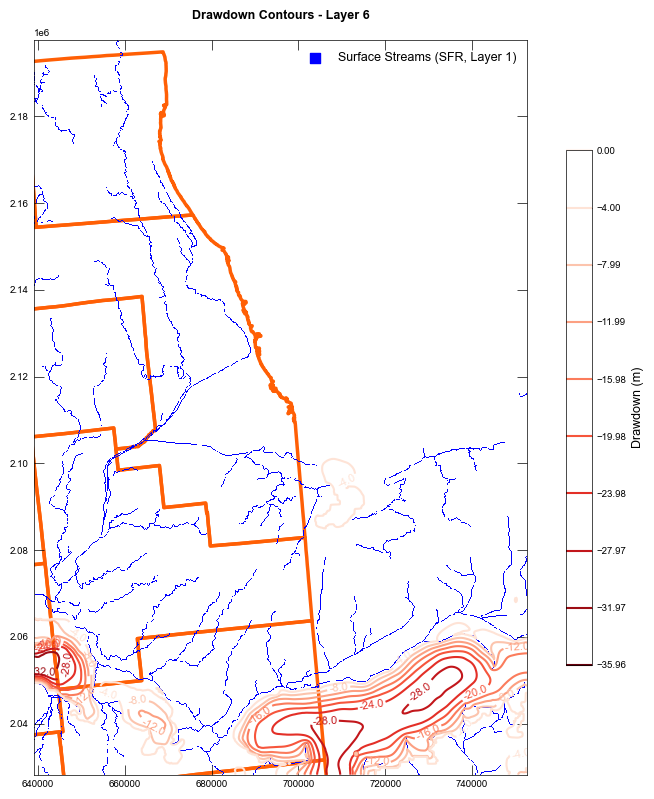

Layer 7 Drawdown Statistics ->
  Min: -35.96
  Max: 0.00
  Median: -0.16
  Mean: -1.85
  Histogram: (array([   526,   1841,   8014,   5596,   4631,   5013,   5133,   5951,
        11712, 433526]), array([-35.96406941, -32.36766247, -28.77125553, -25.17484859,
       -21.57844165, -17.98203471, -14.38562777, -10.78922082,
        -7.19281388,  -3.59640694,   0.        ]))

------------------------------------------------------------


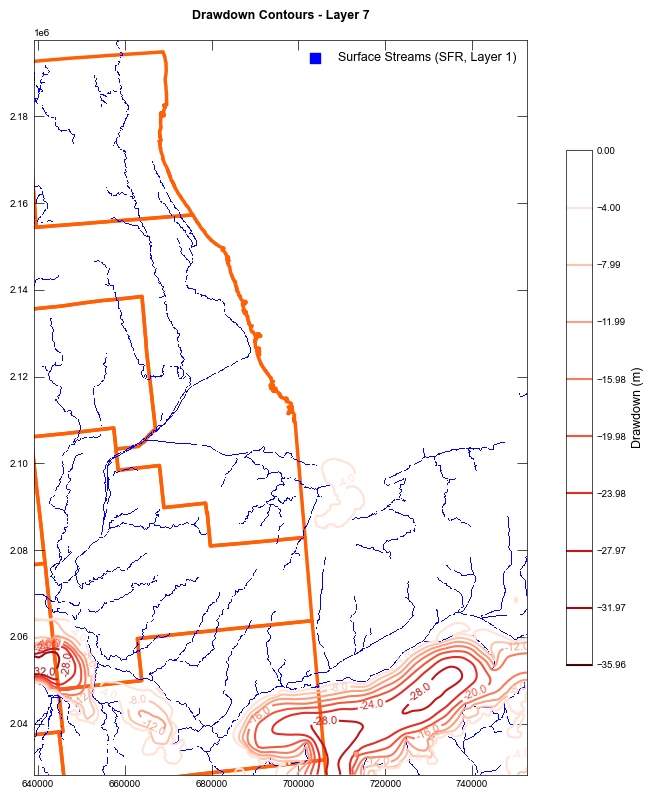

Layer 8 Drawdown Statistics ->
  Min: -35.96
  Max: 0.00
  Median: -0.16
  Mean: -1.85
  Histogram: (array([   525,   1830,   8000,   5613,   4636,   5031,   5141,   5910,
        11770, 433487]), array([-35.96363365, -32.36727029, -28.77090692, -25.17454356,
       -21.57818019, -17.98181683, -14.38545346, -10.7890901 ,
        -7.19272673,  -3.59636337,   0.        ]))

------------------------------------------------------------


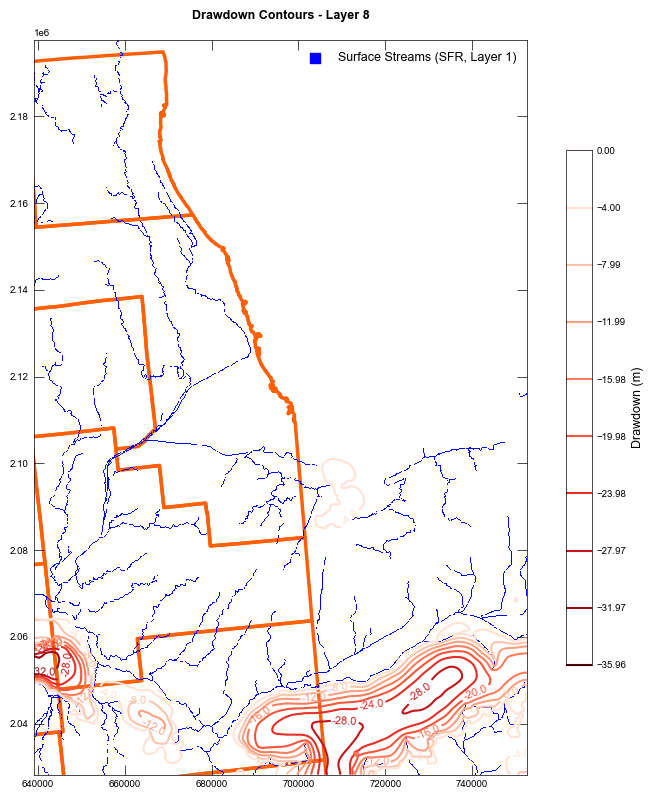

Layer 9 Drawdown Statistics ->
  Min: -35.96
  Max: 0.00
  Median: -0.16
  Mean: -1.85
  Histogram: (array([   525,   1807,   7990,   5629,   4663,   5047,   5130,   5896,
        11790, 433466]), array([-35.96319168, -32.36687251, -28.77055334, -25.17423417,
       -21.57791501, -17.98159584, -14.38527667, -10.7889575 ,
        -7.19263834,  -3.59631917,   0.        ]))

------------------------------------------------------------


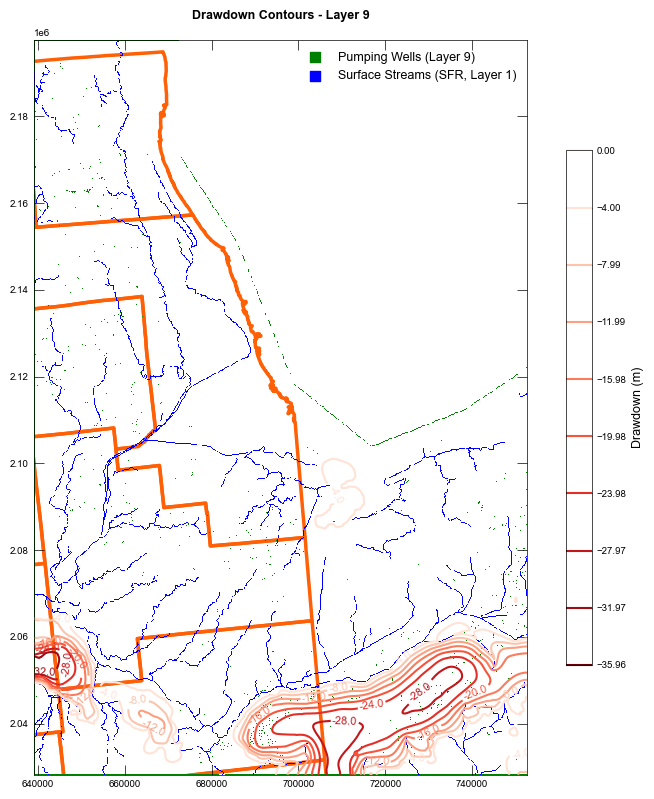

Layer 10 Drawdown Statistics ->
  Min: -35.95
  Max: 0.00
  Median: -0.16
  Mean: -1.86
  Histogram: (array([   525,   1807,   7992,   5632,   4669,   5058,   5113,   5893,
        11792, 433462]), array([-35.9540518 , -32.35864662, -28.76324144, -25.16783626,
       -21.57243108, -17.9770259 , -14.38162072, -10.78621554,
        -7.19081036,  -3.59540518,   0.        ]))

------------------------------------------------------------


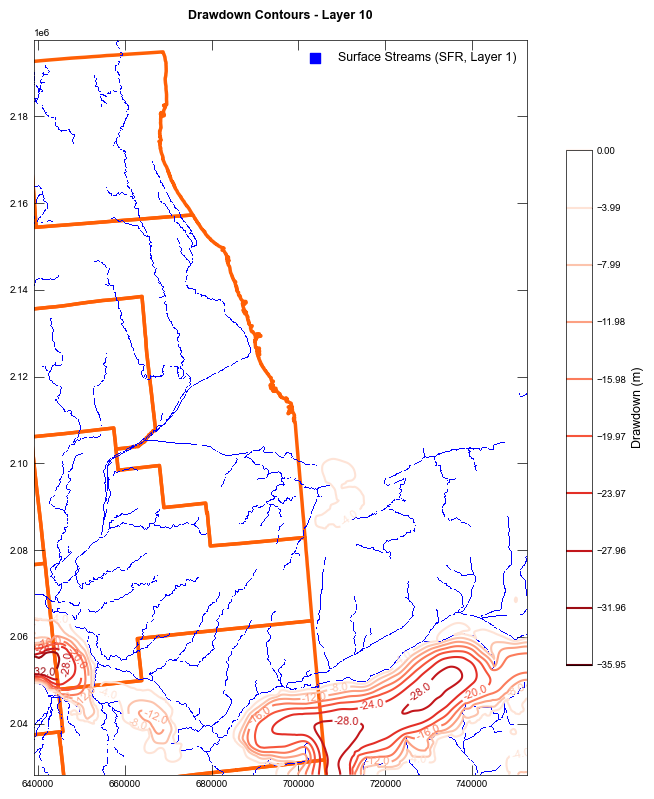

In [21]:
# Loop through each layer and create a contour plot
for layer in range(nlay):
    drawdown_layer_min = drawdown[layer].min()
    drawdown_layer_max = drawdown[layer].max()

    print(f"Layer {layer+1} Drawdown Statistics ->")
    print(f"  Min: {drawdown_layer_min:.2f}")
    print(f"  Max: {drawdown_layer_max:.2f}")
    print(f"  Median: {np.median(drawdown[layer]):.2f}")
    print(f"  Mean: {np.mean(drawdown[layer]):.2f}")
    print(f"  Histogram: {np.histogram(drawdown[layer])}\n")
    print("-" * 60)

    # Create 10 evenly spaced contour intervals between the global min and 0
    levels = np.linspace(drawdown_layer_min, 0.0, 10)
    
    with flopy.plot.styles.USGSMap():
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_title(f"Drawdown Contours - Layer {layer + 1}", fontweight='bold', pad=15)
        ax.set_aspect('equal')
        
        # Initialize the map view for the specific layer
        mapview = flopy.plot.PlotMapView(model=drought_gwf, layer=layer, ax=ax)
        
        # Plot Illinois counties from shapefile for visual reference
        mapview.plot_shapefile(str(shp_path), ax=ax, facecolor="none", edgecolor="#FF5F05", linewidth=2.5)

        # -------------------------------------------------------------
        # Plot Boundaries (Wells and Streams)
        # -------------------------------------------------------------
        # Plot Wells only if we are in Layer 8 (0-based) / Layer 9 (1-based)
        if layer == 8:
            mapview.plot_bc("WEL", color="green")
            ax.scatter([], [], c="green", marker="s", s=50, label="Pumping Wells (Layer 9)")

        # Create a secondary MapView strictly for Layer 0 to plot the surface streams
        mapview_sfr = flopy.plot.PlotMapView(model=base_gwf, layer=0, ax=ax)
        mapview_sfr.plot_bc("SFR", color="blue")
        ax.scatter([], [], c="blue", marker="s", s=50, label="Surface Streams (SFR, Layer 1)")
        
        # Add the legend
        ax.legend(loc="upper right")
        
        # -------------------------------------------------------------
        # Plot Contours
        # -------------------------------------------------------------
        # Using Reds_r so that larger negative drawdowns are darker
        contour_set = mapview.contour_array(drawdown, levels=levels, cmap="Reds_r")
        
        # Add contour labels directly on the lines
        ax.clabel(contour_set, inline=True, fontsize=8, fmt='%1.1f')
        
        # Add a colorbar
        cbar = plt.colorbar(contour_set, ax=ax, shrink=0.7)
        cbar.set_label('Drawdown (m)')
        
        plt.tight_layout()
        plt.show()

### Identifying Anomalous Positive Drawdown

During drought, we expect groundwater heads to **decline** everywhere (negative drawdown).
If any cells show positive drawdown (rising heads), this is anomalous and may indicate:

- **Boundary condition artifacts**: fixed-head or constant-flux boundaries injecting water
- **Streamflow interactions**: stream packages recharging the aquifer more than expected
- **Model instabilities**: numerical artifacts in cells with very thin saturated zones

The code below flags and maps these anomalous cells, skipping layers where none exist.
This focused analysis helps prioritize further investigation.

In [22]:
# Plot bad actors [i.e. drawdown is positive, despite drought conditions]

for layer in range(nlay):
    drawdown_layer_min = drawdown[layer].min()
    drawdown_layer_max = drawdown[layer].max()

    # Cleaned up string formatting for readability
    print(f"Layer {layer+1} Drawdown Statistics ->")
    print(f"  Min: {drawdown_layer_min:.2f}")
    print(f"  Max: {drawdown_layer_max:.2f}")
    print(f"  Median: {np.median(drawdown[layer]):.2f}")
    print(f"  Mean: {np.mean(drawdown[layer]):.2f}")
    print(f"  Histogram: {np.histogram(drawdown[layer])}") 

    # -------------------------------------------------------------
    # SAFETY CHECK: Look before you leap
    # -------------------------------------------------------------
    if drawdown_layer_max <= 0:
        print(f"\n*** No anomalous positive values in Layer {layer + 1}. Skipping plot. ***\n")
        print("-" * 60)
        continue
    
    print(f"\n*** Plotting anomalous values for Layer {layer + 1}... ***\n")
    print("-" * 60)
    
    # Create 10 evenly spaced contour intervals between 0 and the max positive drawdown
    levels = np.linspace(0, drawdown_layer_max, 10) 
    
    with flopy.plot.styles.USGSMap():
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_title(f"Positive Drawdown Contours - Layer {layer + 1}", fontweight='bold', pad=15)
        ax.set_aspect('equal')
        
        # Initialize the map view for the specific layer
        mapview = flopy.plot.PlotMapView(model=drought_gwf, layer=layer, ax=ax)
        
        # Plot Illinois counties from shapefile for visual reference
        mapview.plot_shapefile(str(shp_path), ax=ax, facecolor="none", edgecolor="#FF5F05", linewidth=2.5)
        
        # Plot the contours
        contour_set = mapview.contour_array(drawdown, levels=levels, cmap="Reds")
        
        # Add contour labels directly on the lines
        ax.clabel(contour_set, inline=True, fontsize=8, fmt='%1.1f')
        
        # Add a colorbar
        cbar = plt.colorbar(contour_set, ax=ax, shrink=0.7)
        cbar.set_label('Drawdown (m)')
        
        plt.tight_layout()
        plt.show()

Layer 1 Drawdown Statistics ->
  Min: -35.97
  Max: 0.00
  Median: -0.18
  Mean: -1.86
  Histogram: (array([   534,   1845,   8037,   5572,   4628,   5004,   5123,   5964,
        11756, 433480]), array([-35.96831641, -32.37148477, -28.77465313, -25.17782149,
       -21.58098985, -17.9841582 , -14.38732656, -10.79049492,
        -7.19366328,  -3.59683164,   0.        ]))

*** No anomalous positive values in Layer 1. Skipping plot. ***

------------------------------------------------------------
Layer 2 Drawdown Statistics ->
  Min: -35.97
  Max: 0.00
  Median: -0.17
  Mean: -1.85
  Histogram: (array([   534,   1845,   8036,   5571,   4627,   5007,   5123,   5968,
        11716, 433516]), array([-35.96828572, -32.37145715, -28.77462858, -25.1778    ,
       -21.58097143, -17.98414286, -14.38731429, -10.79048572,
        -7.19365714,  -3.59682857,   0.        ]))

*** No anomalous positive values in Layer 2. Skipping plot. ***

-----------------------------------------------------------

### Exporting Anomalous Cell Data to CSV

To facilitate further investigation, we export all cells with positive drawdown to a CSV file.
For each anomalous cell, we record:

- **Location**: layer, row, column (1-based)
- **Head values**: base and drought heads
- **Drawdown**: the positive value
- **Well presence**: whether a pumping well exists in Layer 9 at the same row/column location
- **Pumping history**: the pumping rate for each stress period if a well is present

The output CSV (`positive_drawdown_anomalies.csv`) can be opened in Excel or GIS software
for spatial analysis and cross-referencing with field data.

In [23]:
# Extract locations and other metadata of bad actors and dump them into a file
# for further investigation.

# Identify indices where drawdown is positive (Anomalies)
positive_indices = np.where(drawdown > 0)
layers, rows, cols = positive_indices
num_anomalies = len(layers)

# Check for anomalies before proceeding with exporting data.
# If there aren't any... no sense in doing extra work.
# "Look before you leap ;)"
if num_anomalies == 0:
    print("Success: No anomalous positive drawdown values detected. Skipping export and processing.")
else:
    print(f"Alert: Found {num_anomalies} cells with unexpected positive drawdown. Processing metadata...")

    # Extract the WEL package data
    nper = drought_gwf.modeltime.nper
    wel_pkg = drought_gwf.wel
    wel_data = wel_pkg.stress_period_data.get_data()

    # Pre-process well data for Layer 9 (index 8)
    layer8_wells = {}
    for sp in range(nper):
        sp_data = wel_data.get(sp, None)
        if sp_data is not None:
            for rec in sp_data:
                k, i, j = rec['cellid']
                q = rec['q']
                
                if k == 8: 
                    if (i, j) not in layer8_wells:
                        layer8_wells[(i, j)] = [0.0] * nper 
                    layer8_wells[(i, j)][sp] += q

    # Build the dataset for the anomalous cells
    records = []
    for k, i, j in zip(layers, rows, cols):
        base_h    = base_heads[k, i, j]
        drought_h = drought_heads[k, i, j]
        dd        = drawdown[k, i, j]
        
        has_well = "Yes" if (i, j) in layer8_wells else "No"
        
        if has_well == "Yes":
            history     = layer8_wells[(i, j)]
            history_str = " | ".join([f"SP{sp}: {q}" for sp, q in enumerate(history)])
        else:
            history_str = "N/A"
            
        records.append({
            "Layer":            k + 1, 
            "Row":              i + 1,
            "Column":           j + 1,
            "Base_Head_m":      round(base_h, 3),
            "Drought_Head_m":   round(drought_h, 3),
            "Drawdown_m":       round(dd, 3),
            "Well_in_Layer_9":  has_well,
            "Pumping_History_m3d": history_str
        })

    # Create DataFrame and export
    df_anomalies = pd.DataFrame(records)
    csv_filename = "positive_drawdown_anomalies.csv"
    df_anomalies.to_csv(csv_filename, index=False)

    print(f"Successfully exported {num_anomalies} anomalies to '{csv_filename}'.")

Success: No anomalous positive drawdown values detected. Skipping export and processing.


### Observation Hydrographs

A **hydrograph** is a time-series plot of groundwater head at a single monitoring location.
During a drought, we expect heads to fall steadily as recharge is reduced. The *rate* and
*magnitude* of that decline vary spatially depending on:

- **Aquifer storativity** — how much water can be released from storage (controlled by Ss and Sy)
- **Distance from pumping wells** — wells accelerate local head decline
- **Proximity to surface water** — streams and Lake Michigan act as partial head-support boundaries

The first code cell below reads the observation CSV output from MODFLOW, prepends the initial
steady-state head at time 0, and plots the **20 observation wells with the largest total head
change** over the drought period.

The second cell maps the spatial locations of those same wells on top of the county boundary
shapefile so you can see *where* in the domain the strongest signals are occurring.

> **Tip:** The observation well names encode their location — for example,
> `gh_l9_r51_c101` is the observation at Layer 9, Row 51, Column 101.

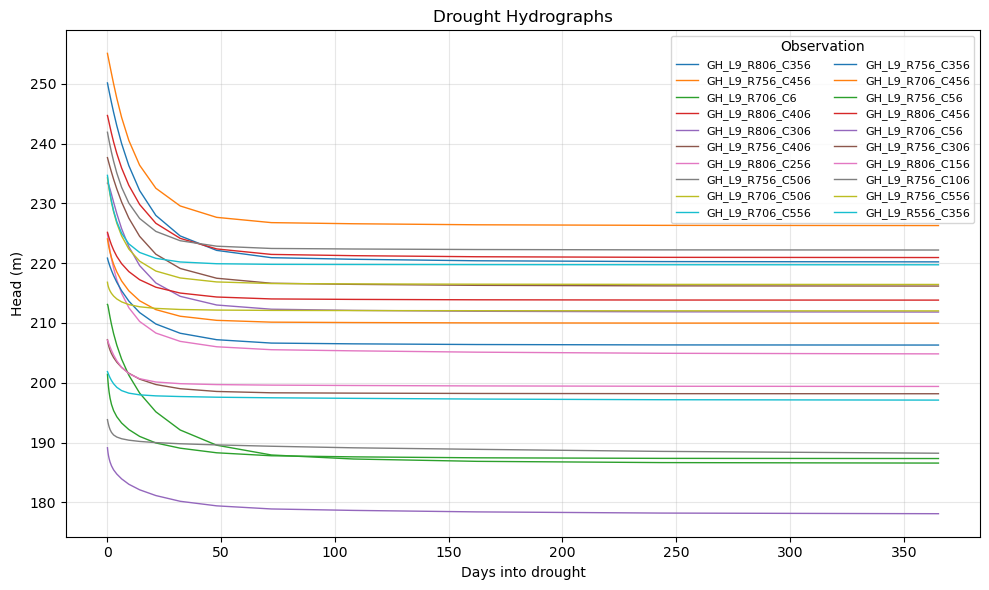

In [24]:
# Plot drought hydrographs from grid OBS output, with initial heads from IC prepended at time 0

drought_obs_heads = pd.read_csv(Path(drought_gwf.model_ws) / "grid_head_obs.csv")

obs_cols = [col for col in drought_obs_heads.columns if col != "time"]

strt = drought_gwf.ic.strt.array

initial_heads = {}
for obs in obs_cols:
    parts = obs.split("_")
    lay = int(parts[1].lower().replace("l", "")) - 1
    row = int(parts[2].lower().replace("r", "")) - 1
    col = int(parts[3].lower().replace("c", "")) - 1
    initial_heads[obs] = strt[lay, row, col]

initial_row = pd.DataFrame(
    [[0.0] + [initial_heads[obs] for obs in obs_cols]],
    columns=["time"] + obs_cols
)

hydrograph = pd.concat(
    [initial_row, drought_obs_heads[["time"] + obs_cols]],
    ignore_index=True
)

# Plot the observation wells with the largest end-of-drought head change
numwells = 20
head_change = hydrograph[obs_cols].iloc[-1] - hydrograph[obs_cols].iloc[0]
obs_to_plot = head_change.abs().sort_values(ascending=False).head(numwells).index

fig, ax = plt.subplots(figsize=(10, 6))

for obs in obs_to_plot:
    ax.plot(hydrograph["time"], hydrograph[obs], linewidth=1, label=obs)

ax.set_xlabel("Days into drought")
ax.set_ylabel("Head (m)")
ax.set_title("Drought Hydrographs")
ax.legend(title="Observation", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

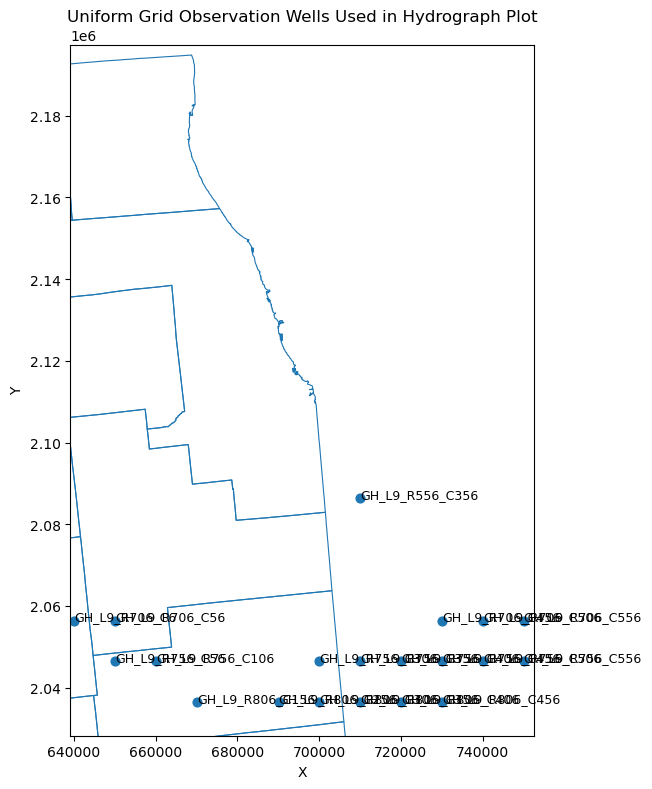

In [25]:
# Map and label the same uniform-grid obs used in the hydrograph plot, with county boundaries

counties = gpd.read_file(shp_path)
counties = counties.to_crs(epsg=5070)

idomain = drought_gwf.dis.idomain.array[0]
xcenters = drought_gwf.modelgrid.xcellcenters
ycenters = drought_gwf.modelgrid.ycellcenters

obs_rows = []

for obs in obs_to_plot:
    parts = obs.split("_")
    lay = int(parts[1].lower().replace("l", "")) - 1
    row = int(parts[2].lower().replace("r", "")) - 1
    col = int(parts[3].lower().replace("c", "")) - 1

    obs_rows.append({
        "obsname": obs,
        "x": xcenters[row, col],
        "y": ycenters[row, col],
        "layer": lay + 1,
        "row": row + 1,
        "col": col + 1,
    })

obs_map = pd.DataFrame(obs_rows)

active = idomain > 0
xmin = xcenters[active].min()
xmax = xcenters[active].max()
ymin = ycenters[active].min()
ymax = ycenters[active].max()

fig, ax = plt.subplots(figsize=(8, 8))

counties.boundary.plot(ax=ax, linewidth=0.8)

ax.scatter(
    obs_map["x"],
    obs_map["y"],
    s=40
)

for _, row in obs_map.iterrows():
    ax.text(row["x"], row["y"], row["obsname"], fontsize=9)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Uniform Grid Observation Wells Used in Hydrograph Plot")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## **Visualizing the Drought: The Interactive Results Dashboard**

In participatory modeling, the ability to **see** and **interact** with model results is just as important as the mathematics behind the simulation. This section of the notebook constructs a comprehensive **Drought Scenario Viewer**—a custom-built interface designed to translate complex MODFLOW 6 groundwater data into an intuitive, visual story.

---

### 🌌 A Water Modeling Parable: "You must unlearn what you have learned"

>  When Luke fails to lift his X-Wing from the Dagobah swamp, it is because he judges the task based on his previous, limited experiences with physics and scale. Yoda tells him he must unlearn what he has learned, proving that "size matters not" and lifting the ship effortlessly.

>  In our previous scenario (`new_demands.ipynb`), we learned to think of aquifer stress in terms of localized demands creating localized "cones of depression" centered around our pumping wells. It is easy to carry that limited experience forward, and make the assumption that domain-wide catastrophic stresses [model-wide drought] must therefore result in domain-wide catastrophic impacts.

As you toggle between the Head and Drawdown modes below, notice that the impact isn't regional. Some locations within our model domain are almost untouched, while others are in a state of complete and utter disaster. To understand the threat of a severe drought, we must "unlearn" our intuition. Although the entire baseline is shifting, and "size matters not" — the drought touches every single cell in the domain — we will still have to adopt localized planning and mitigation strategies.

Use the dashboard below to explore the hydrographs and see just how far and where the water table has fallen across the entire model domain.

---

### **The Data Pipeline**
Before the dashboard can render, we perform two data processing steps:
* **Transient Feature Extraction:** The `extract_transient_data` function reads the raw binary output from our MODFLOW 6 model. It calculates **Drawdown** (how much the water level has dropped compared to normal conditions) and organizes time-series data for every observation point in the grid.
* **Spatial Feature Building:** The `build_static_features` function prepares our "background" layers. It clips regional county boundaries to our model domain and converts model features—like pumping wells, streams, and lake boundaries—into a web-friendly GeoJSON format.

### **Dashboard Functionality**
The `DroughtDashboard` class integrates several powerful libraries (`ipyleaflet` for mapping, `ipywidgets` for controls, and `matplotlib` for graphing) to provide a "multi-sensory" view of the aquifer:

* **🎚️ Display Toggles:** Switch instantly between viewing **Groundwater Heads** (absolute elevation) and **Drawdown** (relative change). 
* **⏳ Time Navigation:** Use the playback buttons to step through the drought timestep-by-timestep. Watch as the "cone[s] of depression" expand/s around areas that are sensitive to reduced recharge over time.
* **🗺️ Dynamic Contouring:** As you change timesteps, the map automatically generates contour lines. These are anchored to a **global color scale**, meaning the colors remain consistent and comparable across the entire simulation duration.
* **🖱️ Real-Time Inspection:** * **Hover:** Move your mouse across the map to see the exact water level or drawdown value for any specific cell.
    * **Click:** Click on any orange observation marker to update the **Hydrograph** below. This shows the "response" of the aquifer at that specific location throughout the entire drought scenario.

---

### **Technical Note for Developers: The Architecture of Interactivity**

The dashboard is built on a **state-driven architecture** that synchronizes standard UI controls with a spatial mapping engine. This coordination ensures that a single user action (like clicking a marker or sliding a toggle) propagates updates across the entire visual suite.

#### **Event-Driven Coordination**
The `DroughtDashboard` class serves as a central controller, wiring together three distinct event types to maintain a single source of "truth":
* **Widget Observations:** Using the `ipywidgets.observe` and `on_click` methods, UI elements like the **Display Toggle** and **Navigation Buttons** trigger internal state changes to the time index or display mode.
* **Map Interactions:** The `ipyleaflet.Map` uses an `on_interaction` listener to capture `mousemove` events. This coordinates with a `pyproj.Transformer` to translate WGS84 coordinates into the model's projected CRS (EPSG:5070), allowing the dashboard to query the underlying **NumPy arrays** and update the **Hover Label** in real-time.
* **Feature Callbacks:** Every observation marker on the map is initialized with a **callback closure**. When a `CircleMarker` is clicked, it identifies itself to the class, which then re-styles all markers to highlight the selection and clears the `ipywidgets.Output` context to re-render the **Matplotlib hydrograph**.

#### **Reactive Spatial Rendering**
To maintain performance with high-density data, the dashboard employs **dynamic layering** rather than full-map refreshes:
* **Layer Groups:** Both contours and observation markers are managed within `ipyleaflet.LayerGroup` objects. This allows the `update_contours` method to swap out GeoJSON payloads for different timesteps without affecting the background tiles or other features.
* **The Output Widget:** The hydrograph is contained within an `ipywidgets.Output` widget. This acts as a dedicated canvas that is cleared and redrawn using `IPython.display.clear_output`, preventing the dashboard from "jumping" or flickering when the plot updates.

By decoupling the data processing (`extract_transient_data`) from the UI logic (`DroughtDashboard`), the system remains responsive even when handling 4D arrays (Time, Layer, Row, Column) representing millions of simulated data points.

> **Note:** Initializing the dashboard may take a few seconds as it calculates the global minimums and maximums across all 4D data arrays to ensure the visual scaling is correct.

---

*Run the cell below to launch the interactive viewer:*

In [26]:
# Extract transient data features
transient_data = extract_transient_data(
                                    drought_gwf,
                                    base_heads,
                                    Path(drought_gwf.model_ws) / "grid_head_obs.csv"
                                    )

# Build static features for plotting display
static_features = build_static_features(drought_gwf,
                                        shp_path,
                                        layer_for_wells=8
                                       )

# Instantiate an instance of the DroughtDashboard class, and display it below
dashboard = DroughtDashboard(drought_gwf,
                             transient_data,
                             static_features,
                             layer=8
                            )

# Take a few seconds. This is a meaty dashboard
dashboard.display()

## *"Always in motion is the future."* 

In this notebook, we shifted from localized planning to system-wide survival. If our previous modeling efforts represented the optimism of building a new well field in a cost-effective and environmentally sustainable effort, a severe drought is our *Empire Strikes Back*—an overwhelming external force that tests our resilience and forces us to adapt. The core themes of the film serve as a metaphorical framework for exploring extreme hydrogeological stress:

* **Acknowledge the Shifting Baseline:** We learned that historical climate "deals" are fragile. By slashing the Recharge (RCH) package, we experienced what happens when nature "alters the deal." We cannot engineer our way out of the inevitability of drought; we must use our models to anticipate the new terms and adapt to survive them.
* **Test Your Assumptions:** Like the dark side cave on Dagobah, a model under extreme stress only shows you what you take with you. When we saw cells going dry or convergence warnings, we recognized that the model was revealing the limits and blind spots of our own conceptual assumptions.
* **Rely on Your Defenses:** With our annual recharge "shield generator" turned off, we saw how the aquifer must rely entirely on its finite internal volume—Specific Storage and Specific Yield—to endure the continuous bombardment of pumping demands.
* **Unlearn Your Intuition:** It is easy to assume that a system-wide lack of rain will cause a uniform, flat drop in water levels across the board. The model proved otherwise—some locations barely registered the drought, while others suffered extreme, localized drawdown. We had to "unlearn what we had learned" about simple cause-and-effect. A severe drought doesn't lower the water table evenly; it acts as a stress test that mercilessly exposes hidden geological inequalities and pre-existing vulnerabilities of the aquifer.

### Technical Accomplishments
In completing this scenario, you:

1. ✅ Loaded the IISG base model and its steady-state heads
2. ✅ Copied the base model to a new workspace without altering the original
3. ✅ Converted the simulation from steady-state to transient (one-year stress period)
4. ✅ Added storage parameters (Ss and Sy) required for transient simulation
5. ✅ Updated initial conditions and stress period data for the drought scenario
6. ✅ Configured a uniform grid of observation points to capture spatial head variability
7. ✅ Ran the modified drought simulation
8. ✅ Computed and mapped drawdown contours across all model layers
9. ✅ Identified, mapped, and exported anomalous positive drawdown cells
10. ✅ Plotted hydrographs for the hardest-hit observation locations and mapped their positions
11. ✅ Explored results interactively with the **DroughtDashboard** — stepping through time and clicking on observation wells to compare individual hydrographs

### Suggested Extensions

- **Pray I Don't Alter It Any Further:** Adjust `drought_factor` to an even more extreme low (e.g., 0.10) to see at what point the model entirely fails to converge, effectively breaking the physical assumptions of the system.
- **Surviving the Carbon Freeze:** Increase `num_periods` and vary the recharge stress period data to simulate a multi-year, prolonged drought, followed by a slow return to normal precipitation. How many years does it take the aquifer to "thaw" and recover its baseline heads?
- **Imperial Probe Droids:** Use the DroughtDashboard to pinpoint exactly which observation wells act as your "probe droids"—showing the earliest and steepest signals of the advancing drought before the rest of the grid reacts.
- **Into the Asteroid Field:** Investigate the anomalous positive drawdown cells by joining your exported CSV with a model grid shapefile in GIS. Are these numerical "illusions" caused by model boundaries, or are they hiding deeper hydrogeological dynamics?
- **Never Tell Me the Odds:** Combine the stresses. Merge the localized pumping demands from `new_demands.ipynb` into this regional drought model. Can your selected township survive the Empire and a harsh environment simultaneously, or does the local aquifer collapse?